Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

Load Data

In [2]:
df = pd.read_csv('E:\Textbook\proj\ML_Project\data\cs-training.csv', index_col=0)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\T'
C:\Users\marti\AppData\Local\Temp\ipykernel_16772\4069691563.py:1: SyntaxWarning: invalid escape sequence '\T'
  df = pd.read_csv('E:\Textbook\proj\ML_Project\data\cs-training.csv', index_col=0)


Shape: (150000, 11)

Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Rename Columns

In [3]:
df.columns = [
    'defaulted',           # target
    'revolving_util',      # credit card usage ratio
    'age',
    'late_30_59',          # times 30-59 days late
    'debt_ratio',
    'monthly_income',
    'open_credit_lines',
    'late_90',             # times 90+ days late
    'real_estate_loans',
    'late_60_89',          # times 60-89 days late
    'dependents'
]

df.head()

,defaulted,revolving_util,age,late_30_59,debt_ratio,monthly_income,open_credit_lines,late_90,real_estate_loans,late_60_89,dependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Basic Info

In [4]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

print("\n=== Basic Stats ===")
df.describe().round(2)

=== Data Types ===
defaulted              int64
revolving_util       float64
age                    int64
late_30_59             int64
debt_ratio           float64
monthly_income       float64
open_credit_lines      int64
late_90                int64
real_estate_loans      int64
late_60_89             int64
dependents           float64
dtype: object

=== Missing Values ===
defaulted                0
revolving_util           0
age                      0
late_30_59               0
debt_ratio               0
monthly_income       29731
open_credit_lines        0
late_90                  0
real_estate_loans        0
late_60_89               0
dependents            3924
dtype: int64

Total missing: 33655

=== Basic Stats ===


,defaulted,revolving_util,age,late_30_59,debt_ratio,monthly_income,open_credit_lines,late_90,real_estate_loans,late_60_89,dependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


Target Distribution

=== Class Distribution ===
Non-default (0): 139,974 (93.3%)
Default     (1): 10,026 (6.7%)


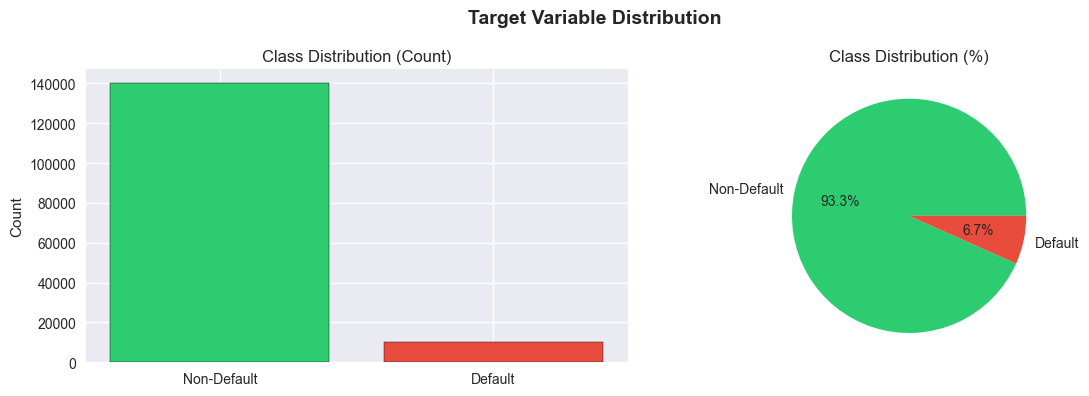


⚠️  Dataset is heavily imbalanced — important for model training!


In [6]:
counts = df['defaulted'].value_counts()
pct = df['defaulted'].value_counts(normalize=True) * 100

print("=== Class Distribution ===")
print(f"Non-default (0): {counts[0]:,} ({pct[0]:.1f}%)")
print(f"Default     (1): {counts[1]:,} ({pct[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Non-Default', 'Default'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['Non-Default', 'Default'],colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%')
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⚠️  Dataset is heavily imbalanced — important for model training!")

Age Analysis

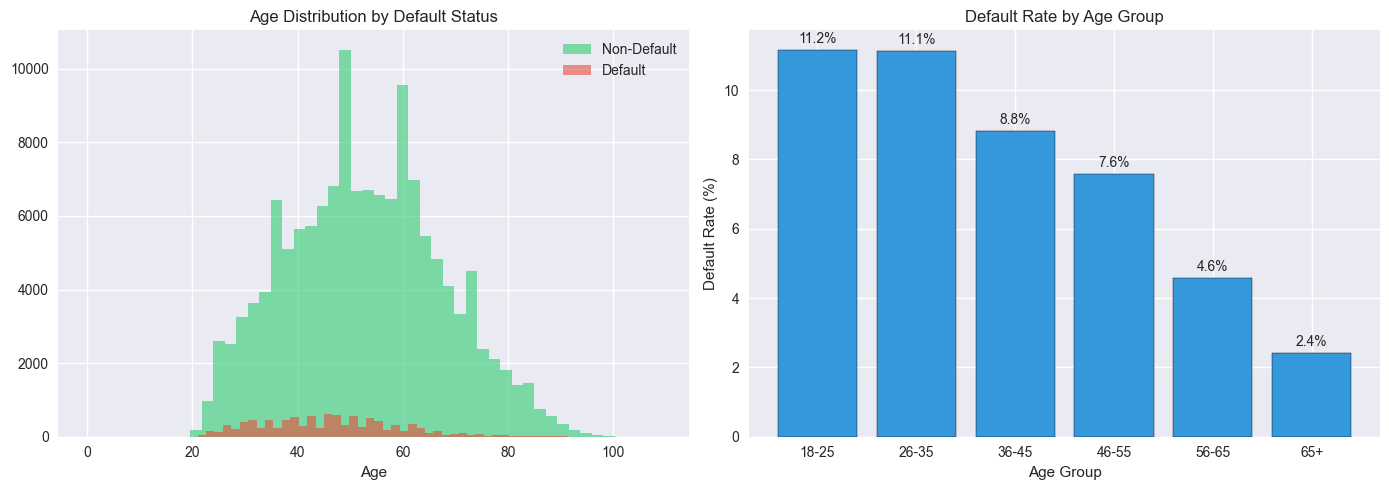

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df[df['defaulted']==0]['age'], bins=50, alpha=0.6, color='#2ecc71', label='Non-Default')
axes[0].hist(df[df['defaulted']==1]['age'], bins=50, alpha=0.6, color='#e74c3c', label='Default')
axes[0].set_title('Age Distribution by Default Status')
axes[0].set_xlabel('Age')
axes[0].legend()

# Default rate by age group
df['age_group'] = pd.cut(df['age'], bins=[18,25,35,45,55,65,120],labels=['18-25','26-35','36-45','46-55','56-65','65+'])
default_by_age = df.groupby('age_group')['defaulted'].mean() * 100

axes[1].bar(default_by_age.index, default_by_age.values, color='#3498db', edgecolor='black')
axes[1].set_title('Default Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Default Rate (%)')

for i, v in enumerate(default_by_age.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../assets/age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Credit Utilization vs Default

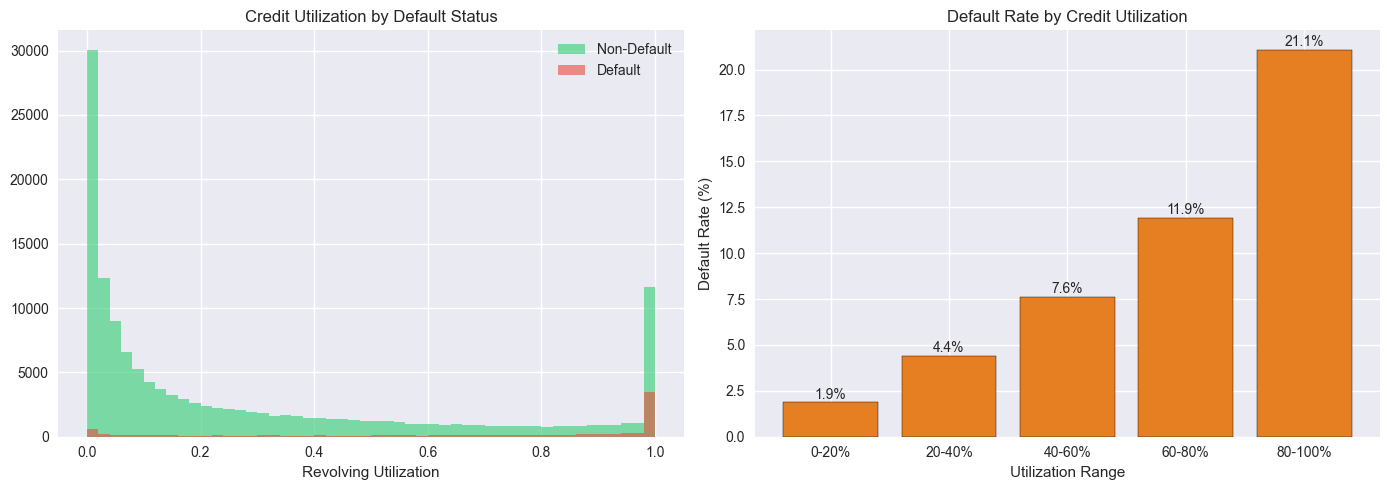

In [9]:
# Cap outliers for visualization
util = df['revolving_util'].clip(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(util[df['defaulted']==0], bins=50, alpha=0.6,color='#2ecc71', label='Non-Default')
axes[0].hist(util[df['defaulted']==1], bins=50, alpha=0.6,color='#e74c3c', label='Default')
axes[0].set_title('Credit Utilization by Default Status')
axes[0].set_xlabel('Revolving Utilization')
axes[0].legend()

# Bucket utilization
df['util_group'] = pd.cut(util, bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],labels=['0-20%','20-40%','40-60%','60-80%','80-100%'])
default_by_util = df.groupby('util_group')['defaulted'].mean() * 100

axes[1].bar(default_by_util.index, default_by_util.values,color='#e67e22', edgecolor='black')
axes[1].set_title('Default Rate by Credit Utilization')
axes[1].set_xlabel('Utilization Range')
axes[1].set_ylabel('Default Rate (%)')

for i, v in enumerate(default_by_util.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../assets/utilization_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation Heatmap

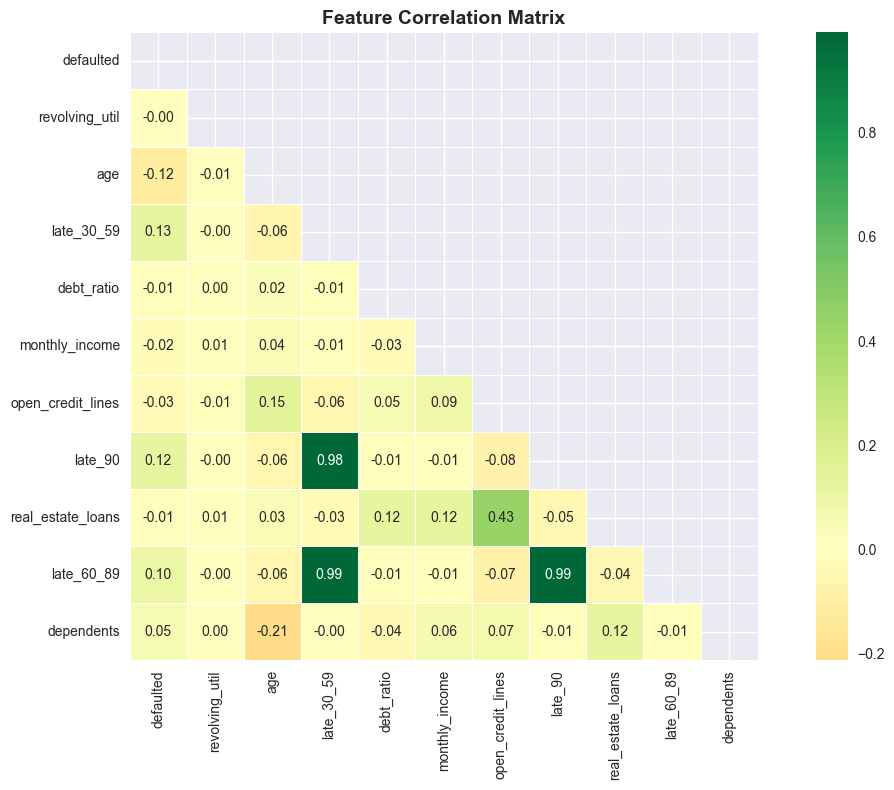


=== Top correlations with default ===
defaulted            1.000000
late_30_59           0.125587
late_90              0.117175
late_60_89           0.102261
dependents           0.046048
revolving_util      -0.001802
real_estate_loans   -0.007038
debt_ratio          -0.007602
monthly_income      -0.019746
open_credit_lines   -0.029669
age                 -0.115386
Name: defaulted, dtype: float64


In [10]:
plt.figure(figsize=(12, 8))

corr = df[['defaulted','revolving_util','age','late_30_59','debt_ratio','monthly_income','open_credit_lines','late_90','real_estate_loans','late_60_89','dependents']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,square=True, linewidths=0.5)

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Top correlations with default ===")
print(corr['defaulted'].sort_values(ascending=False))

Missing Value Handling

In [12]:
print("Before cleaning:")
print(df[['monthly_income','dependents']].isnull().sum())

# Fix for pandas 2.0+ — assign back instead of inplace
df['monthly_income'] = df['monthly_income'].fillna(df['monthly_income'].median())
df['dependents'] = df['dependents'].fillna(df['dependents'].median())

# Remove bad rows
df = df[df['age'] > 18]
df['revolving_util'] = df['revolving_util'].clip(0, 1)
df['debt_ratio'] = df['debt_ratio'].clip(0, df['debt_ratio'].quantile(0.99))

print("\nAfter cleaning:")
print(df.isnull().sum().sum(), "missing values remaining")
print("Shape:", df.shape)

Before cleaning:
monthly_income    29731
dependents         3924
dtype: int64

After cleaning:
10878 missing values remaining
Shape: (149999, 13)


Save Clean Data

In [14]:
df_clean = df.drop(['age_group', 'util_group'], axis=1)

df_clean.to_csv('../data/cs-training-clean.csv', index=False)
print("✅ Clean dataset saved!")
print(f"Final shape: {df_clean.shape}")
print(f"\nFeatures: {df_clean.columns.tolist()}")

✅ Clean dataset saved!
Final shape: (149999, 11)

Features: ['defaulted', 'revolving_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_income', 'open_credit_lines', 'late_90', 'real_estate_loans', 'late_60_89', 'dependents']


In [15]:
print(df_clean.isnull().sum().sum())  # should be 0
print(df_clean.shape)                  # should be (149999, 11)
print(df_clean['defaulted'].value_counts())

0
(149999, 11)
defaulted
0    139973
1     10026
Name: count, dtype: int64
